# Brain Tumor MRI Classification: A Comparative Study of CNN, Transfer Learning, and Hybrid CNN-ViT Approaches

**Models trained:**
1. Custom CNN (baseline, trained from scratch)
2. MobileNetV2 (transfer learning)
3. EfficientNetB0 (transfer learning)
4. **EffViT-Hybrid** (novel: EfficientNetB0 convolutional stem + ViT-Tiny encoder)

**Dataset:** Nickparvar Brain Tumor MRI Dataset (Kaggle) — 7,023 images, 4 classes (glioma, meningioma, notumor, pituitary)

---

## Section 1: Setup & Imports

In [ ]:
import os
import time
import json
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('float32')
print(f"Precision policy: {mixed_precision.global_policy()}")

# GPU check
print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")


POSSIBLE_PATHS = [
    '/kaggle/input/brain-tumor-mri-dataset',
    '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset',
]
DATA_DIR = None
for p in POSSIBLE_PATHS:
    if os.path.exists(os.path.join(p, 'Training')):
        DATA_DIR = p
        break

if DATA_DIR is None:

    for root, dirs, files in os.walk('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'):
        if 'Training' in dirs and 'Testing' in dirs:
            DATA_DIR = root
            break

assert DATA_DIR is not None, "Could not locate dataset. Make sure to add the Brain Tumor MRI Dataset as input."
TRAIN_DIR = os.path.join(DATA_DIR, 'Training')
TEST_DIR = os.path.join(DATA_DIR, 'Testing')
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)


IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f"\nDataset path: {DATA_DIR}")
print(f"Training dir exists: {os.path.exists(TRAIN_DIR)}")
print(f"Testing dir exists: {os.path.exists(TEST_DIR)}")

2026-05-12 06:19:32.082727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778566772.299298      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778566772.361224      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778566772.878815      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778566772.878871      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778566772.878874      57 computation_placer.cc:177] computation placer alr

Precision policy: <DTypePolicy "float32">
TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Dataset path: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
Training dir exists: True
Testing dir exists: True


## Section 2: Dataset Loading & Exploratory Data Analysis

Training set distribution:
  glioma         : 1400
  meningioma     : 1400
  notumor        : 1400
  pituitary      : 1400
  TOTAL          : 5600

Testing set distribution:
  glioma         : 400
  meningioma     : 400
  notumor        : 400
  pituitary      : 400
  TOTAL          : 1600


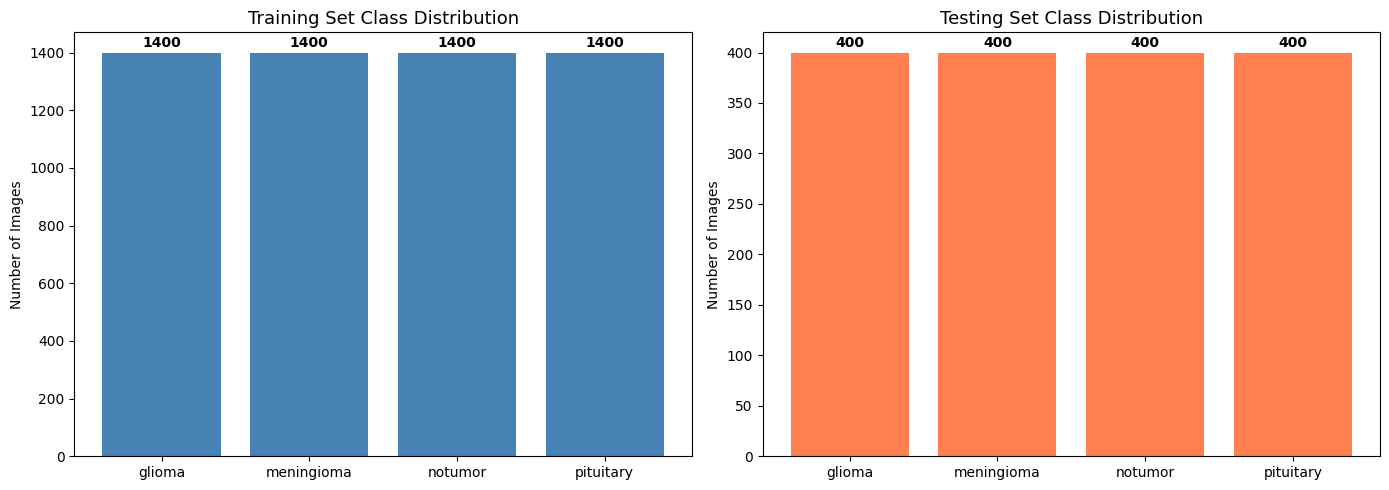

In [ ]:
def count_images(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training set distribution:")
for k, v in train_counts.items():
    print(f"  {k:15s}: {v}")
print(f"  {'TOTAL':15s}: {sum(train_counts.values())}")

print("\nTesting set distribution:")
for k, v in test_counts.items():
    print(f"  {k:15s}: {v}")
print(f"  {'TOTAL':15s}: {sum(test_counts.values())}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue')
axes[0].set_title('Training Set Class Distribution', fontsize=13)
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(train_counts.values()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color='coral')
axes[1].set_title('Testing Set Class Distribution', fontsize=13)
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(test_counts.values()):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

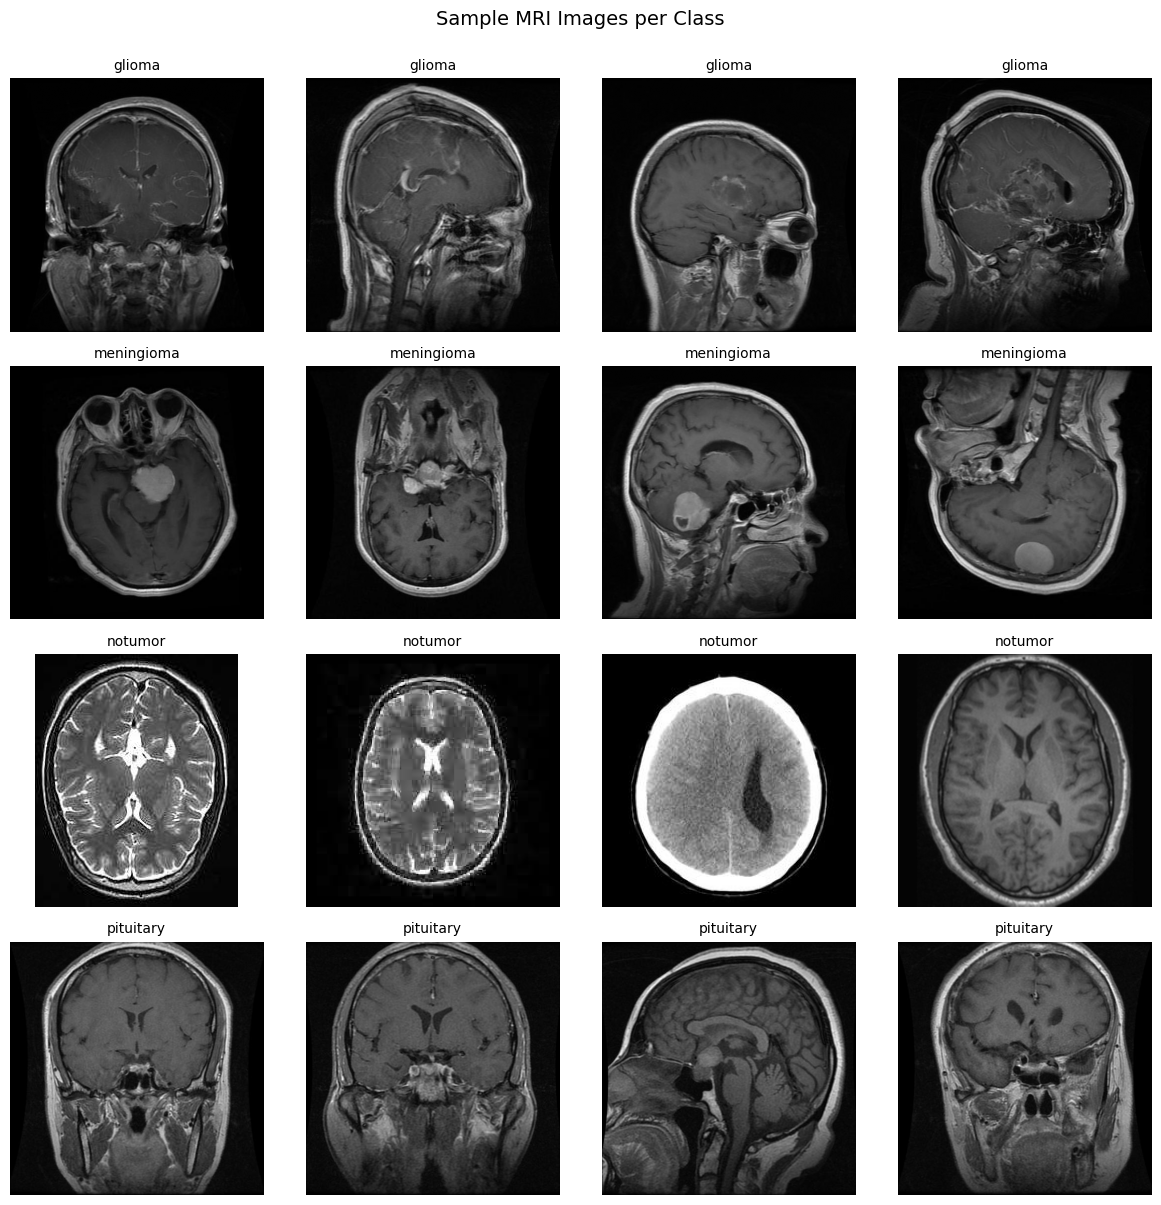

In [3]:
# Visualize sample images from each class
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for row, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    sample_files = sorted(os.listdir(class_dir))[:4]
    for col, fname in enumerate(sample_files):
        img = Image.open(os.path.join(class_dir, fname))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'{class_name}', fontsize=10)
        axes[row, col].axis('off')
plt.suptitle('Sample MRI Images per Class', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Data Preprocessing & Augmentation Pipelines

**Two separate generators** are used because different models expect different input ranges:

| Pipeline | Pixel Range | Used by |
|---|---|---|
| **A (rescaled)** | `[0, 1]` | Custom CNN, MobileNetV2 |
| **B (raw)** | `[0, 255]` | EfficientNetB0, EffViT-Hybrid |

EfficientNet has a built-in `Normalization` layer that expects raw 0-255 pixel values, so pre-rescaling them to `[0, 1]` breaks the model. This is a well-documented Keras gotcha.

In [ ]:

train_datagen_A = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    validation_split=0.15,
    fill_mode='nearest'
)
test_datagen_A = ImageDataGenerator(rescale=1./255)

train_gen_A = train_datagen_A.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    subset='training', shuffle=True, seed=SEED
)
val_gen_A = train_datagen_A.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    subset='validation', shuffle=False, seed=SEED
)
test_gen_A = test_datagen_A.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False
)

# ===== PIPELINE B: raw [0, 255] — for EfficientNet and Hybrid =====
train_datagen_B = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    validation_split=0.15,
    fill_mode='nearest'
)
test_datagen_B = ImageDataGenerator()

train_gen_B = train_datagen_B.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    subset='training', shuffle=True, seed=SEED
)
val_gen_B = train_datagen_B.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    subset='validation', shuffle=False, seed=SEED
)
test_gen_B = test_datagen_B.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False
)

print(f"\nPipeline A (rescaled [0,1]): {train_gen_A.samples} train | {val_gen_A.samples} val | {test_gen_A.samples} test")
print(f"Pipeline B (raw [0,255]):    {train_gen_B.samples} train | {val_gen_B.samples} val | {test_gen_B.samples} test")
print(f"Classes: {train_gen_A.class_indices}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Pipeline A (rescaled [0,1]): 4760 train | 840 val | 1600 test
Pipeline B (raw [0,255]):    4760 train | 840 val | 1600 test
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Section 4: Utility Functions

Shared helpers for training, evaluation, and plotting. Functions accept generator references so the same training loop works for both pipelines A and B.

In [5]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(
            f'{OUTPUT_DIR}/{model_name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        )
    ]

def train_model(model, model_name, train_g, val_g, epochs=EPOCHS):
    print(f"\n{'='*60}\nTraining: {model_name}")
    print(f"Total params: {model.count_params():,}")
    print(f"{'='*60}\n")
    start = time.time()
    history = model.fit(
        train_g, validation_data=val_g, epochs=epochs,
        callbacks=get_callbacks(model_name), verbose=1
    )
    train_time = time.time() - start
    print(f"\nTraining time: {train_time:.1f}s ({train_time/60:.1f} min)")
    return history, train_time

def evaluate_model(model, model_name, test_g):
    print(f"\nEvaluating {model_name}...")
    test_g.reset()
    start = time.time()
    y_pred_probs = model.predict(test_g, verbose=1)
    inference_time = (time.time() - start) / test_g.samples * 1000  # ms per image
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_g.classes
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\nClassification Report — {model_name}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    return {
        'model': model_name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'inference_ms_per_image': inference_time,
        'params_M': model.count_params() / 1e6,
        'y_true': y_true, 'y_pred': y_pred,
        'y_pred_probs': y_pred_probs, 'confusion_matrix': cm
    }

def plot_training_history(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    axes[0].set_title(f'{model_name} — Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'{model_name} — Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

class CombinedHistory:
    """Wraps a dict to mimic Keras History object for plotting."""
    def __init__(self, h): self.history = h

all_results = {}
all_histories = {}
all_train_times = {}

print("Utilities ready.")

Utilities ready.


## Section 5: Model 1 — Custom CNN (Baseline)

3-block convolutional network trained from scratch. Uses Pipeline A (rescaled `[0, 1]`).

In [6]:
def build_custom_cnn():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name='Custom_CNN')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_cnn = build_custom_cnn()
model_cnn.summary()

I0000 00:00:1778566807.741274      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,956 (1.23 MB)

 Trainable params: 321,508 (1.23 MB)

 Non-trainable params: 448 (1.75 KB)


Training: CustomCNN
Total params: 321,956

Epoch 1/30


I0000 00:00:1778566814.784720     172 service.cc:152] XLA service 0x7a29441070a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778566814.784771     172 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778566815.705912     172 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/149 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.2812 - loss: 1.7102 

I0000 00:00:1778566827.591952     172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 140s 834ms/step - accuracy: 0.4903 - loss: 1.1626 - val_accuracy: 0.2512 - val_loss: 1.6505 - learning_rate: 1.0000e-04
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 574ms/step - accuracy: 0.6733 - loss: 0.8092 - val_accuracy: 0.2571 - val_loss: 1.9325 - learning_rate: 1.0000e-04
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 567ms/step - accuracy: 0.7316 - loss: 0.6890 - val_accuracy: 0.3857 - val_loss: 1.9570 - learning_rate: 1.0000e-04
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7326 - loss: 0.6592
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 556ms/step - accuracy: 0.7326 - loss: 0.6592 - val_accuracy: 0.4571 - val_loss: 1.7923 - learning_rate: 1.0000e-04
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 565ms/step - accuracy: 0.7490 - loss: 0.6263 - val_accuracy: 0.4774 - val_loss: 1.6146 - learning_rate: 5.0000e-05
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 86s 576ms/step - accur

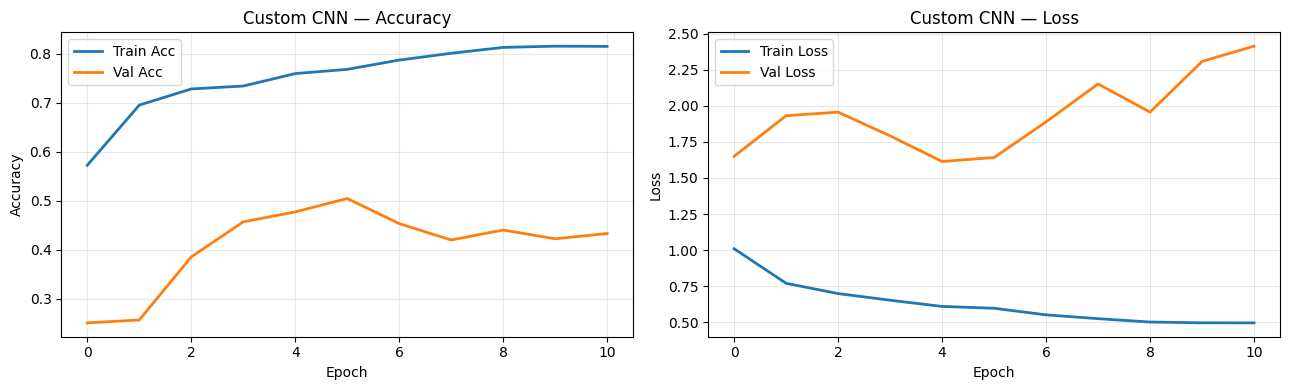


Evaluating CustomCNN...
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step

Classification Report — CustomCNN
              precision    recall  f1-score   support

      glioma       0.46      0.73      0.56       400
  meningioma       0.67      0.01      0.01       400
     notumor       0.95      0.10      0.18       400
   pituitary       0.42      0.96      0.58       400

    accuracy                           0.45      1600
   macro avg       0.62      0.45      0.33      1600
weighted avg       0.62      0.45      0.33      1600



In [7]:
history_cnn, time_cnn = train_model(model_cnn, 'CustomCNN', train_gen_A, val_gen_A, epochs=EPOCHS)
all_histories['CustomCNN'] = history_cnn
all_train_times['CustomCNN'] = time_cnn

plot_training_history(history_cnn, 'Custom CNN', f'{OUTPUT_DIR}/CustomCNN_training.png')
all_results['CustomCNN'] = evaluate_model(model_cnn, 'CustomCNN', test_gen_A)

## Section 6: Model 2 — MobileNetV2 (Transfer Learning)

Lightweight ImageNet pre-trained architecture (~3.5M params). Uses Pipeline A (rescaled `[0, 1]`). MobileNetV2 accepts `[0, 1]` inputs without issue.

Two-stage training: (1) frozen base + head only, (2) unfreeze top 30 layers and fine-tune.

In [8]:
def build_mobilenet():
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name='MobileNetV2')
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base

model_mn, base_mn = build_mobilenet()
model_mn.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Training: MobileNetV2
Total params: 2,422,468

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 119s 701ms/step - accuracy: 0.4116 - loss: 1.3729 - val_accuracy: 0.8214 - val_loss: 0.5793 - learning_rate: 1.0000e-04
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 86s 580ms/step - accuracy: 0.7214 - loss: 0.7102 - val_accuracy: 0.8440 - val_loss: 0.4417 - learning_rate: 1.0000e-04
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 570ms/step - accuracy: 0.7891 - loss: 0.5503 - val_accuracy: 0.8655 - val_loss: 0.3936 - learning_rate: 1.0000e-04
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 560ms/step - accuracy: 0.8140 - loss: 0.5030 - val_accuracy: 0.8595 - val_loss: 0.3802 - learning_rate: 1.0000e-04
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 552ms/step - accuracy: 0.8109 - loss: 0.4915 - val_accuracy: 0.8810 - val_loss: 0.3402 - learning_rate: 1.0000e-04
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 547ms/step - accuracy: 0.8345 - loss: 0.4277 - val_accuracy: 0.8893 - val_loss: 0.3131 - learning_rate: 1.0000e-

2026-05-12 07:04:41.776181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:04:41.973811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/149 ━━━━━━━━━━━━━━━━━━━━ 57s 404ms/step - accuracy: 0.5682 - loss: 1.4643

2026-05-12 07:04:53.386421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:04:53.585927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


149/149 ━━━━━━━━━━━━━━━━━━━━ 115s 650ms/step - accuracy: 0.7222 - loss: 0.7768 - val_accuracy: 0.8238 - val_loss: 0.4083 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 540ms/step - accuracy: 0.8596 - loss: 0.3798 - val_accuracy: 0.8571 - val_loss: 0.3616 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 537ms/step - accuracy: 0.8732 - loss: 0.3266 - val_accuracy: 0.8774 - val_loss: 0.2966 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 525ms/step - accuracy: 0.8920 - loss: 0.3130 - val_accuracy: 0.8762 - val_loss: 0.2933 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 538ms/step - accuracy: 0.8868 - loss: 0.2915 - val_accuracy: 0.9060 - val_loss: 0.2525 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 539ms/step - accuracy: 0.9087 - loss: 0.2466 - val_accuracy: 0.9167 - val_loss: 0.2363 - learning_rate: 1.0000e-05
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 539ms/step -

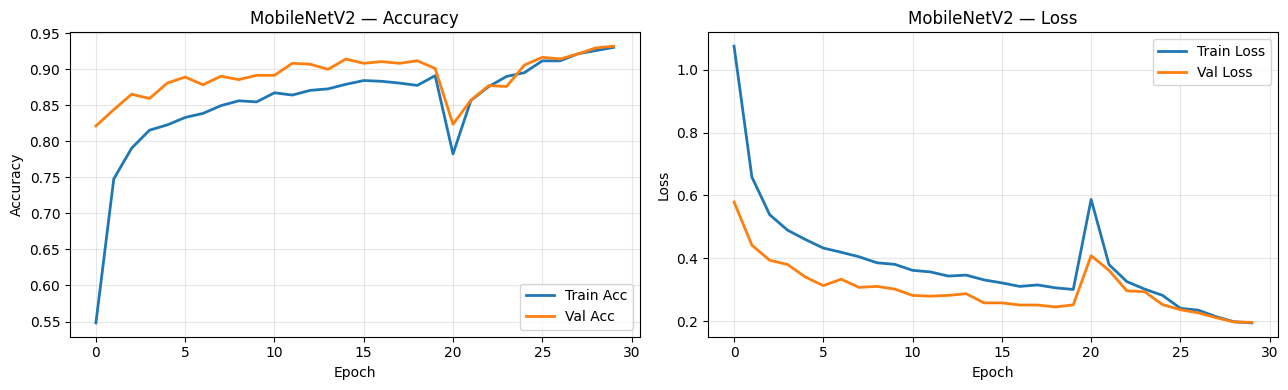


Evaluating MobileNetV2...
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step

Classification Report — MobileNetV2
              precision    recall  f1-score   support

      glioma       0.96      0.74      0.84       400
  meningioma       0.81      0.81      0.81       400
     notumor       0.90      0.99      0.95       400
   pituitary       0.87      0.99      0.93       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



In [9]:
# Stage 1: frozen base
history_mn1, time_mn1 = train_model(model_mn, 'MobileNetV2', train_gen_A, val_gen_A, epochs=20)

# Stage 2: fine-tune top 30 layers
print("\n=== Fine-tuning MobileNetV2 ===")
base_mn.trainable = True
for layer in base_mn.layers[:-30]:
    layer.trainable = False
model_mn.compile(optimizer=Adam(learning_rate=1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])
history_mn2, time_mn2 = train_model(model_mn, 'MobileNetV2_ft', train_gen_A, val_gen_A, epochs=10)

# Combine histories
combined = CombinedHistory({
    'accuracy':     history_mn1.history['accuracy']     + history_mn2.history['accuracy'],
    'val_accuracy': history_mn1.history['val_accuracy'] + history_mn2.history['val_accuracy'],
    'loss':         history_mn1.history['loss']         + history_mn2.history['loss'],
    'val_loss':     history_mn1.history['val_loss']     + history_mn2.history['val_loss']
})
all_histories['MobileNetV2'] = combined
all_train_times['MobileNetV2'] = time_mn1 + time_mn2

plot_training_history(combined, 'MobileNetV2', f'{OUTPUT_DIR}/MobileNetV2_training.png')
all_results['MobileNetV2'] = evaluate_model(model_mn, 'MobileNetV2', test_gen_A)

## Section 7: Model 3 — EfficientNetB0 (Transfer Learning)

Modern compound-scaled architecture (~5.3M params). **Uses Pipeline B (raw `[0, 255]`)** because EfficientNet has built-in normalization.

Same two-stage training recipe as MobileNetV2.

In [10]:
def build_efficientnet():
    base = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                          include_top=False, weights='imagenet')
    base.trainable = False
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name='EfficientNetB0')
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base

model_eff, base_eff = build_efficientnet()
model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Training: EfficientNetB0
Total params: 4,214,055

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 129s 709ms/step - accuracy: 0.4509 - loss: 1.2284 - val_accuracy: 0.7714 - val_loss: 0.6486 - learning_rate: 1.0000e-04
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 534ms/step - accuracy: 0.7271 - loss: 0.7062 - val_accuracy: 0.8286 - val_loss: 0.5054 - learning_rate: 1.0000e-04
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 533ms/step - accuracy: 0.7682 - loss: 0.6049 - val_accuracy: 0.8321 - val_loss: 0.4569 - learning_rate: 1.0000e-04
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 539ms/step - accuracy: 0.8027 - loss: 0.5169 - val_accuracy: 0.8619 - val_loss: 0.4039 - learning_rate: 1.0000e-04
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 535ms/step - accuracy: 0.8161 - loss: 0.4913 - val_accuracy: 0.8583 - val_loss: 0.3798 - learning_rate: 1.0000e-04
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 538ms/step - accuracy: 0.8225 - loss: 0.4707 - val_accuracy: 0.8619 - val_loss: 0.3727 - learning_rate: 1.000

2026-05-12 07:46:39.847307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:46:40.054985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:46:40.475301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:46:40.682834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 72/149 ━━━━━━━━━━━━━━━━━━━━ 35s 455ms/step - accuracy: 0.7682 - loss: 0.5990

2026-05-12 07:47:29.579979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:47:29.789693: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:47:30.200343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 07:47:30.409872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


149/149 ━━━━━━━━━━━━━━━━━━━━ 144s 742ms/step - accuracy: 0.7760 - loss: 0.5886 - val_accuracy: 0.8702 - val_loss: 0.3298 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 547ms/step - accuracy: 0.8224 - loss: 0.4843 - val_accuracy: 0.8929 - val_loss: 0.3396 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 537ms/step - accuracy: 0.8507 - loss: 0.4184 - val_accuracy: 0.8917 - val_loss: 0.3227 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 530ms/step - accuracy: 0.8634 - loss: 0.3805 - val_accuracy: 0.8940 - val_loss: 0.3020 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 539ms/step - accuracy: 0.8595 - loss: 0.3816 - val_accuracy: 0.8905 - val_loss: 0.2918 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 543ms/step - accuracy: 0.8862 - loss: 0.3170 - val_accuracy: 0.8952 - val_loss: 0.2782 - learning_rate: 1.0000e-05
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 526ms/step -

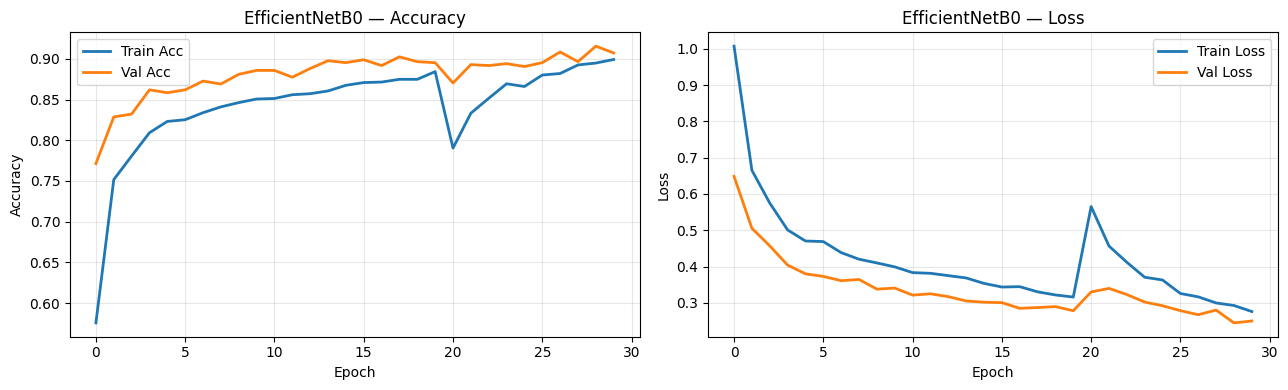


Evaluating EfficientNetB0...
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step

Classification Report — EfficientNetB0
              precision    recall  f1-score   support

      glioma       0.94      0.67      0.78       400
  meningioma       0.79      0.78      0.78       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.86      0.99      0.92       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



In [11]:
# Stage 1: frozen base — use PIPELINE B (raw [0, 255])
history_eff1, time_eff1 = train_model(model_eff, 'EfficientNetB0', train_gen_B, val_gen_B, epochs=20)

# Stage 2: fine-tune top 30 layers
print("\n=== Fine-tuning EfficientNetB0 ===")
base_eff.trainable = True
for layer in base_eff.layers[:-30]:
    layer.trainable = False
model_eff.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
history_eff2, time_eff2 = train_model(model_eff, 'EfficientNetB0_ft', train_gen_B, val_gen_B, epochs=10)

combined_eff = CombinedHistory({
    'accuracy':     history_eff1.history['accuracy']     + history_eff2.history['accuracy'],
    'val_accuracy': history_eff1.history['val_accuracy'] + history_eff2.history['val_accuracy'],
    'loss':         history_eff1.history['loss']         + history_eff2.history['loss'],
    'val_loss':     history_eff1.history['val_loss']     + history_eff2.history['val_loss']
})
all_histories['EfficientNetB0'] = combined_eff
all_train_times['EfficientNetB0'] = time_eff1 + time_eff2

plot_training_history(combined_eff, 'EfficientNetB0', f'{OUTPUT_DIR}/EfficientNetB0_training.png')
all_results['EfficientNetB0'] = evaluate_model(model_eff, 'EfficientNetB0', test_gen_B)

## Section 8: Model 4 — EffViT-Hybrid (Novel Architecture)

**Pattern 3 hybrid:** EfficientNetB0 convolutional stem + ViT-Tiny transformer encoder.

The CNN stem provides local inductive bias (translation invariance, locality). The transformer encoder captures global context through self-attention. This design combines the sample efficiency of CNNs with the global receptive field of transformers.

**Architecture:**
- EfficientNetB0 blocks → 14×14×112 feature map (`block5c_add`)
- 1×1 Conv projection → 14×14×192 (ViT-Tiny embedding dim)
- Patchify → 196 tokens × 192 dim
- Learnable positional embedding + CLS token
- 6 transformer encoder layers (6 heads, MLP dim 768)
- CLS token → Dense classifier

Uses Pipeline B (raw `[0, 255]`).

In [12]:
class TransformerBlock(layers.Layer):
    """Standard pre-norm ViT encoder block."""
    def __init__(self, embed_dim=192, num_heads=6, mlp_dim=768, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads,
                                              key_dim=embed_dim // num_heads,
                                              dropout=dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        h = self.norm1(x)
        h = self.attn(h, h, training=training)
        x = x + h
        h = self.norm2(x)
        h = self.mlp(h, training=training)
        x = x + h
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim, 'num_heads': self.num_heads,
            'mlp_dim': self.mlp_dim, 'dropout': self.dropout_rate
        })
        return config


class AddPositionalEmbedding(layers.Layer):
    """Adds learnable positional embedding + prepends a learnable CLS token."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer='random_normal', trainable=True, name='cls_token'
        )
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer='random_normal', trainable=True, name='pos_embed'
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x = tf.concat([cls_tokens, x], axis=1)
        x = x + self.pos_embed
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches, 'embed_dim': self.embed_dim})
        return config


def build_effvit_hybrid(embed_dim=192, num_heads=6, num_layers=6, mlp_dim=768):
    # CNN stem: EfficientNetB0 truncated at block5c_add → (14, 14, 112)
    base = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                          include_top=False, weights='imagenet')
    base.trainable = False
    cnn_features = base.get_layer('block5c_add').output
    cnn_backbone = Model(base.input, cnn_features, name='effnet_stem')

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = cnn_backbone(inputs, training=False)               # (B, 14, 14, 112)
    x = layers.Conv2D(embed_dim, kernel_size=1, padding='same', name='patch_proj')(x)  # (B, 14, 14, 192)

    h, w = x.shape[1], x.shape[2]
    num_patches = h * w  # 196
    x = layers.Reshape((num_patches, embed_dim))(x)        # (B, 196, 192)

    x = AddPositionalEmbedding(num_patches, embed_dim, name='pos_embed_layer')(x)  # (B, 197, 192)

    for i in range(num_layers):
        x = TransformerBlock(embed_dim=embed_dim, num_heads=num_heads,
                             mlp_dim=mlp_dim, dropout=0.1,
                             name=f'transformer_{i}')(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    cls_output = layers.Lambda(lambda t: t[:, 0], name='cls_extract')(x)
    cls_output = layers.Dropout(0.3)(cls_output)
    cls_output = layers.Dense(128, activation='relu')(cls_output)
    cls_output = layers.Dropout(0.3)(cls_output)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(cls_output)

    model = Model(inputs, outputs, name='EffViT_Hybrid')
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base

model_hybrid, base_hybrid = build_effvit_hybrid()
print(f"\nTotal params: {model_hybrid.count_params():,}")
trainable_count = sum([tf.size(v).numpy() for v in model_hybrid.trainable_variables])
print(f"Trainable params: {trainable_count:,}")


Total params: 3,622,475
Trainable params: 2,754,500



Training: EffViT_Hybrid
Total params: 3,622,475

Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 176s 822ms/step - accuracy: 0.5063 - loss: 1.1744 - val_accuracy: 0.8179 - val_loss: 0.5008 - learning_rate: 1.0000e-04
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 540ms/step - accuracy: 0.7984 - loss: 0.5312 - val_accuracy: 0.8321 - val_loss: 0.4351 - learning_rate: 1.0000e-04
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 543ms/step - accuracy: 0.8520 - loss: 0.3987 - val_accuracy: 0.8810 - val_loss: 0.3260 - learning_rate: 1.0000e-04
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 514ms/step - accuracy: 0.8713 - loss: 0.3438 - val_accuracy: 0.8774 - val_loss: 0.3408 - learning_rate: 1.0000e-04
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 517ms/step - accuracy: 0.8848 - loss: 0.3247 - val_accuracy: 0.8821 - val_loss: 0.3213 - learning_rate: 1.0000e-04
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.8991 - loss: 0.3102 - val_accuracy: 0.8857 - val_loss: 0.3055 - learning_rate: 1.0000

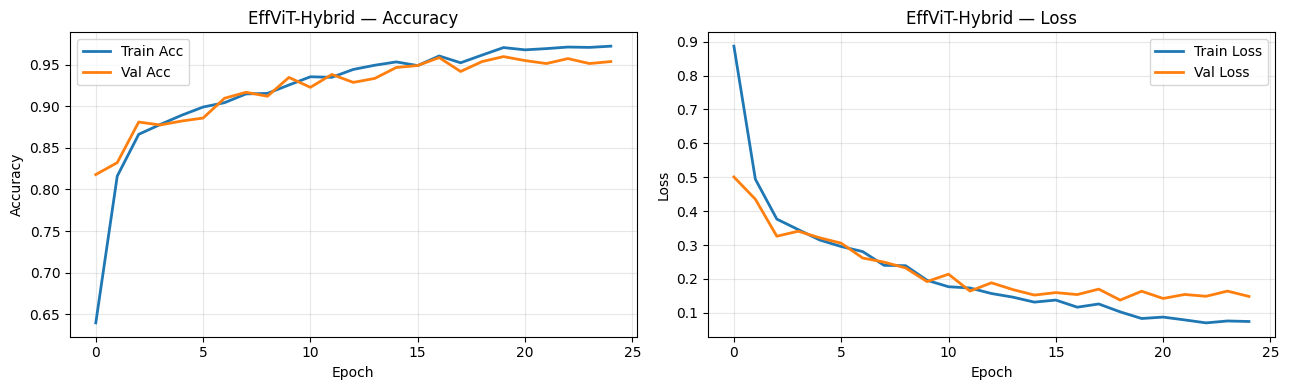


Evaluating EffViT_Hybrid...
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step

Classification Report — EffViT_Hybrid
              precision    recall  f1-score   support

      glioma       0.96      0.79      0.87       400
  meningioma       0.88      0.90      0.89       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.94      0.99      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [13]:
# Train hybrid: CNN stem frozen, transformer trains from scratch
# Uses PIPELINE B (raw [0, 255])
history_hybrid, time_hybrid = train_model(model_hybrid, 'EffViT_Hybrid',
                                          train_gen_B, val_gen_B, epochs=EPOCHS)

all_histories['EffViT_Hybrid'] = history_hybrid
all_train_times['EffViT_Hybrid'] = time_hybrid

plot_training_history(history_hybrid, 'EffViT-Hybrid', f'{OUTPUT_DIR}/EffViT_Hybrid_training.png')
all_results['EffViT_Hybrid'] = evaluate_model(model_hybrid, 'EffViT_Hybrid', test_gen_B)

## Section 9: Comparative Evaluation — All 4 Models

Side-by-side comparison: accuracy, precision, recall, F1, inference time, and parameter count.

In [14]:
# Summary table
summary_data = []
for name, res in all_results.items():
    summary_data.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall': f"{res['recall']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'Params (M)': f"{res['params_M']:.2f}",
        'Inference (ms/img)': f"{res['inference_ms_per_image']:.2f}",
        'Train Time (s)': f"{all_train_times[name]:.1f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("FINAL COMPARISON TABLE")
print("="*100)
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{OUTPUT_DIR}/results_summary.csv', index=False)
print(f"\nResults saved to {OUTPUT_DIR}/results_summary.csv")


FINAL COMPARISON TABLE
         Model Accuracy Precision Recall F1-Score Params (M) Inference (ms/img) Train Time (s)
     CustomCNN   0.4475    0.6230 0.4475   0.3325       0.32              10.04          988.4
   MobileNetV2   0.8825    0.8872 0.8825   0.8798       2.42               6.52         2485.9
EfficientNetB0   0.8544    0.8603 0.8544   0.8491       4.21               7.11         2522.0
 EffViT_Hybrid   0.9194    0.9211 0.9194   0.9176       3.62               7.70         2014.4

Results saved to /kaggle/working/results_summary.csv


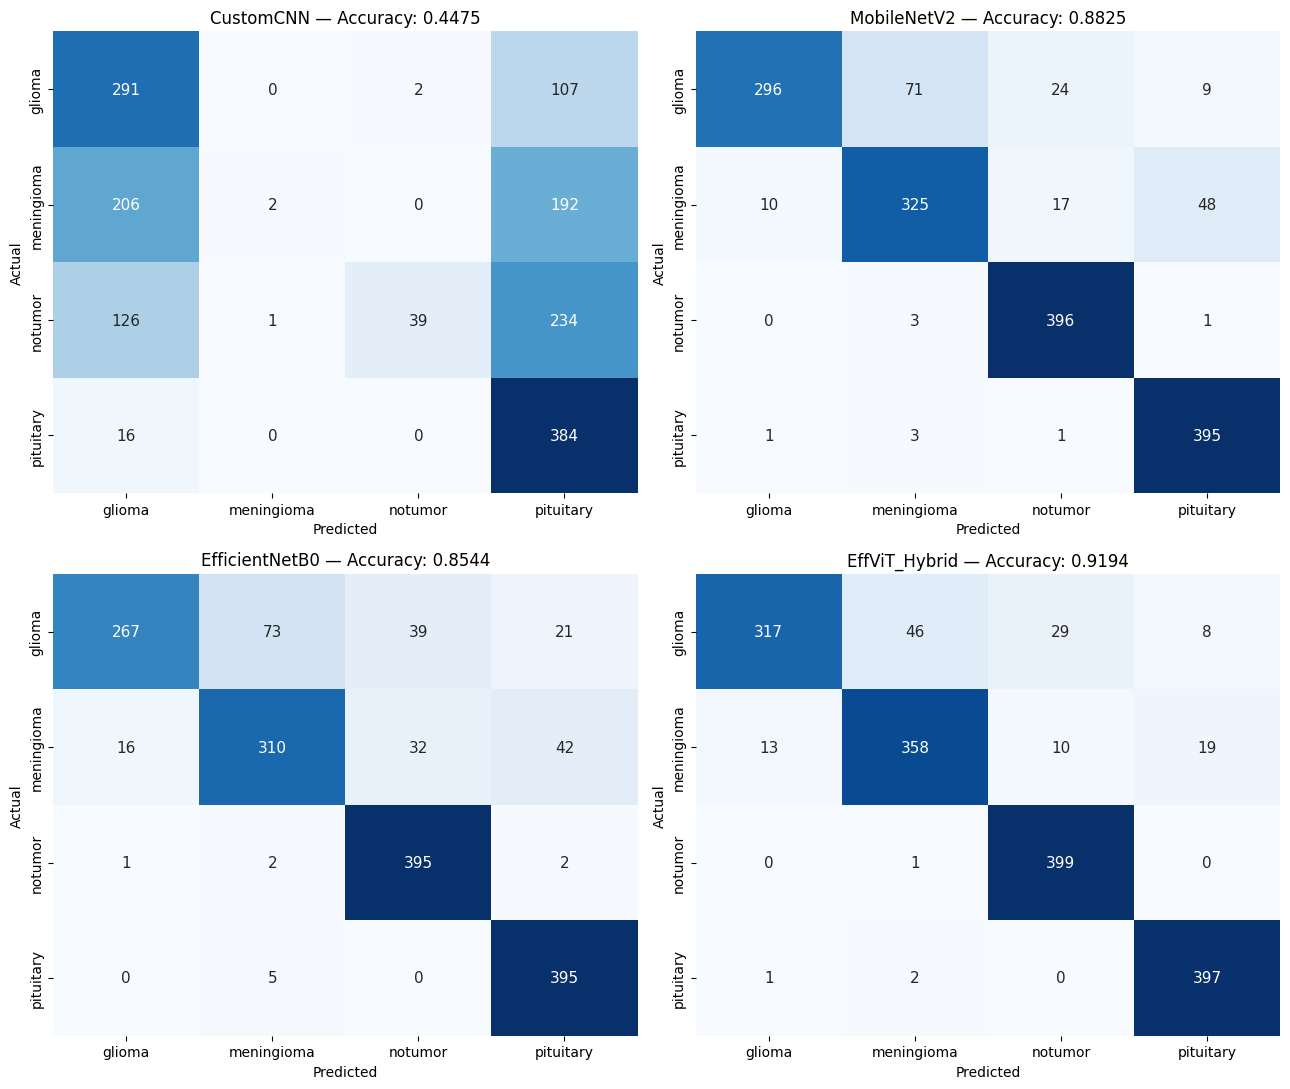

In [15]:
# Confusion matrices — 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, res) in zip(axes.flat, all_results.items()):
    cm = res['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={'size': 11})
    ax.set_title(f'{name} — Accuracy: {res["accuracy"]:.4f}', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

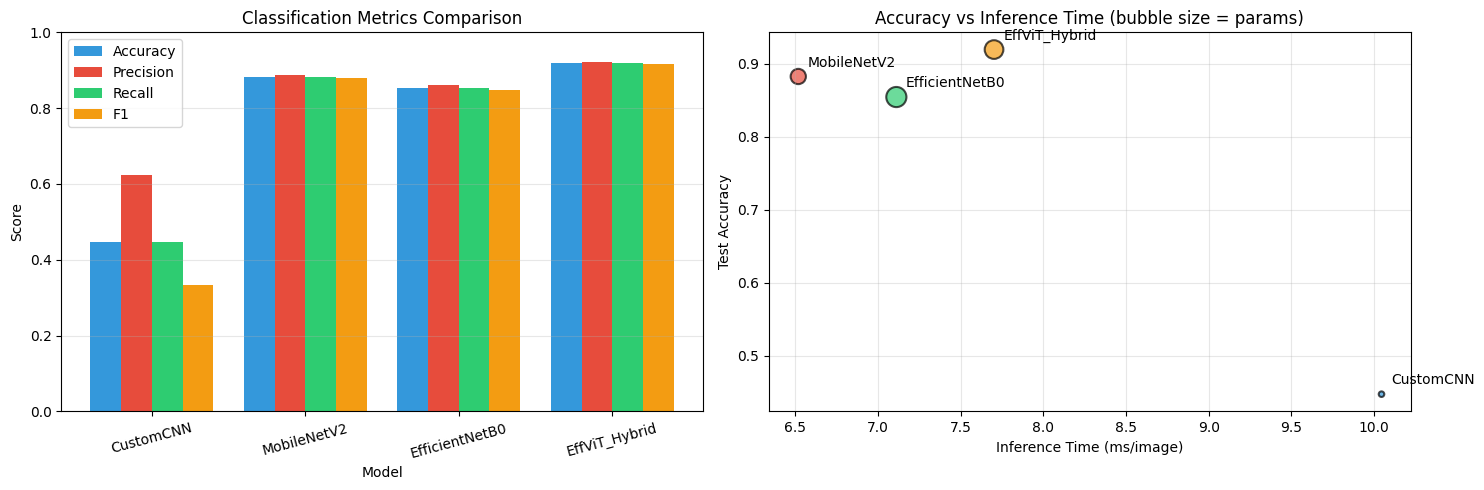

In [16]:
# Metrics bar chart + accuracy-vs-inference scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models = list(all_results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(models))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [all_results[m][metric] for m in models]
    axes[0].bar(x + i*width, values, width, label=label, color=colors[i])
axes[0].set_xlabel('Model'); axes[0].set_ylabel('Score')
axes[0].set_title('Classification Metrics Comparison')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.0])

inf_times = [all_results[m]['inference_ms_per_image'] for m in models]
accuracies = [all_results[m]['accuracy'] for m in models]
params = [all_results[m]['params_M'] for m in models]

axes[1].scatter(inf_times, accuracies,
                s=[p*50 for p in params],
                c=colors, alpha=0.7, edgecolors='black', linewidth=1.5)
for i, m in enumerate(models):
    axes[1].annotate(m, (inf_times[i], accuracies[i]),
                    xytext=(7, 7), textcoords='offset points', fontsize=10)
axes[1].set_xlabel('Inference Time (ms/image)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy vs Inference Time (bubble size = params)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

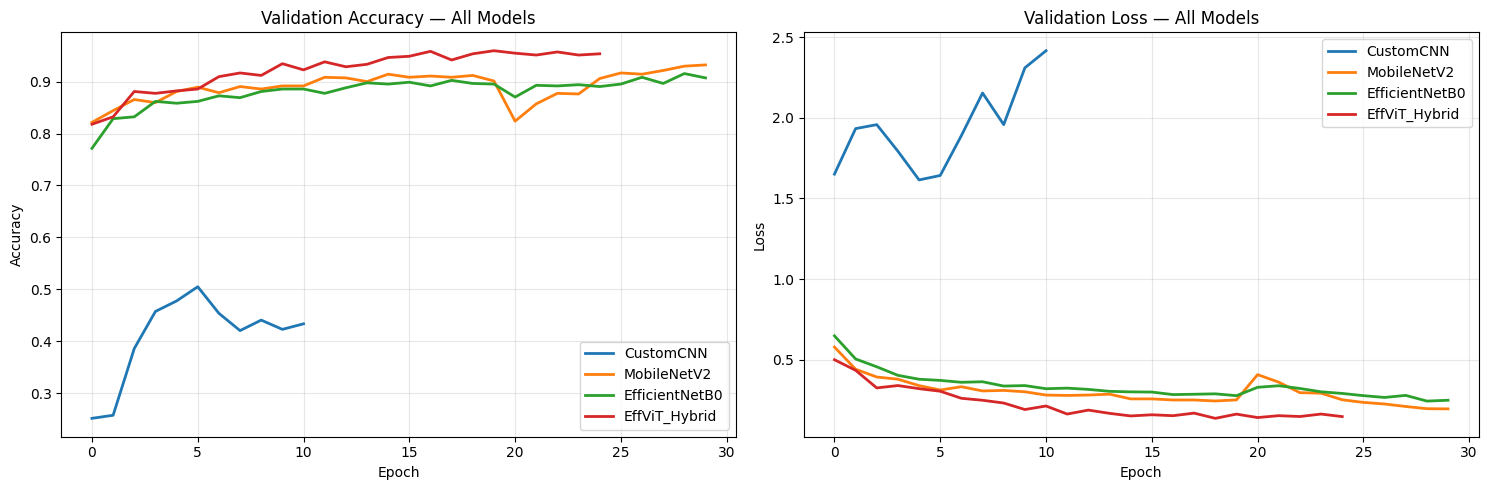

In [17]:
# Combined validation curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, hist in all_histories.items():
    axes[0].plot(hist.history['val_accuracy'], label=name, linewidth=2)
    axes[1].plot(hist.history['val_loss'], label=name, linewidth=2)
axes[0].set_title('Validation Accuracy — All Models'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Loss — All Models'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/all_models_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Grad-CAM Visualizations

Visual explanations showing which regions of the MRI the model attends to when making predictions. Applied to **EfficientNetB0** (one of the best CNN-based models).

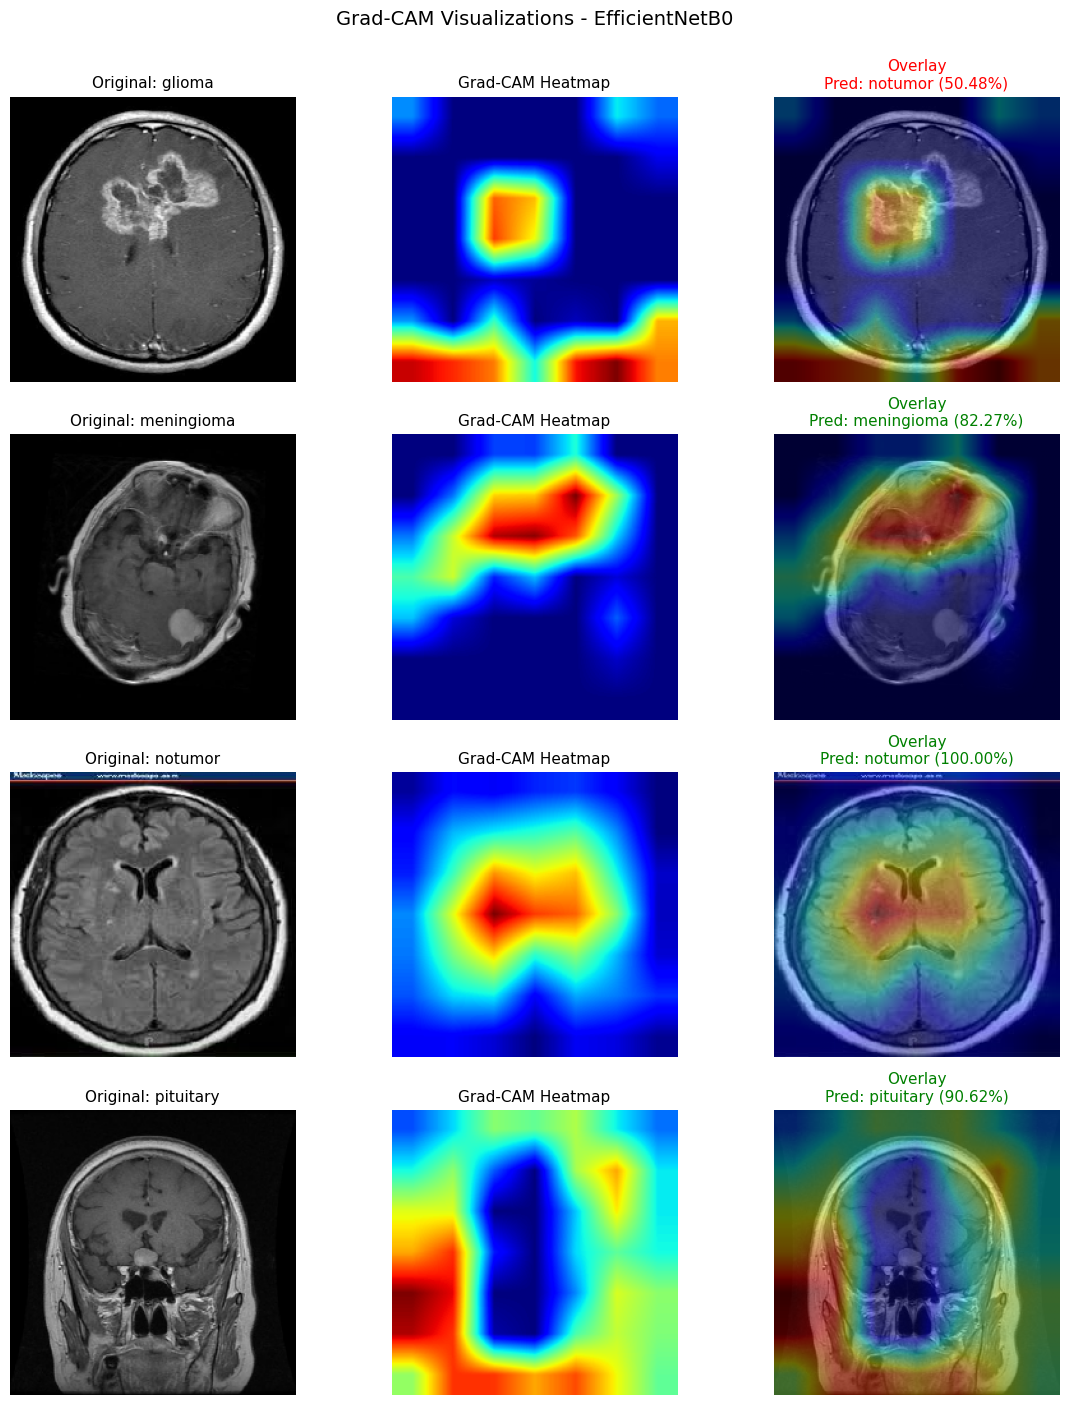

In [18]:
import cv2

def get_gradcam_heatmap(img_array, full_model, conv_layer_name='top_conv', pred_index=None):
    """
    Compute Grad-CAM heatmap for the EfficientNetB0-based model.

    Notes:
    - img_array must match the training distribution. Our EfficientNet was trained
      with PIPELINE B (raw [0, 255]), so we pass raw pixel values here.
    - Because the EfficientNet is wrapped as a sub-model inside `full_model`, we
      cannot directly Bridge the inner conv layer to the outer input. Instead we
      build a (base.input -> conv_output, base.output) sub-model, then manually
      propagate base.output through the remaining head layers of full_model.
    """
    # Find the EfficientNet sub-model inside full_model
    base_submodel = None
    for layer in full_model.layers:
        if isinstance(layer, tf.keras.Model) and 'efficientnet' in layer.name.lower():
            base_submodel = layer
            break
    if base_submodel is None:
        raise RuntimeError("EfficientNetB0 sub-model not found inside full_model")

    # Sub-model that yields (target_conv_output, base_features) from a raw image
    grad_base = Model(
        base_submodel.input,
        [base_submodel.get_layer(conv_layer_name).output, base_submodel.output],
        name='grad_base'
    )

    # Collect the head layers (everything after the EfficientNet sub-model)
    head_layers = []
    found_base = False
    for layer in full_model.layers:
        if isinstance(layer, tf.keras.Model) and 'efficientnet' in layer.name.lower():
            found_base = True
            continue
        if found_base and not isinstance(layer, layers.InputLayer):
            head_layers.append(layer)

    with tf.GradientTape() as tape:
        conv_output, base_features = grad_base(img_array, training=False)
        # Propagate through the head manually
        h = base_features
        for hl in head_layers:
            h = hl(h, training=False)
        preds = h
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), int(pred_index), float(preds[0][pred_index].numpy())

# Sample one image per class and visualize Grad-CAM
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for row, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TEST_DIR, class_name)
    sample_file = sorted(os.listdir(class_dir))[0]
    img_path = os.path.join(class_dir, sample_file)

    # Load raw [0, 255] for EfficientNet (matches Pipeline B training distribution)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr_raw = tf.keras.preprocessing.image.img_to_array(img)   # [0, 255]
    img_arr_display = img_arr_raw / 255.0                          # [0, 1] for display only
    img_batch = np.expand_dims(img_arr_raw, axis=0)

    heatmap, pred_idx, conf = get_gradcam_heatmap(img_batch, model_eff)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]
    overlay = np.clip(img_arr_display * 0.6 + heatmap_colored * 0.4, 0, 1)

    axes[row, 0].imshow(img_arr_display)
    axes[row, 0].set_title(f'Original: {class_name}', fontsize=11)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap_resized, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=11)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    pred_name = CLASS_NAMES[pred_idx]
    color = 'green' if pred_name == class_name else 'red'
    axes[row, 2].set_title(f'Overlay\nPred: {pred_name} ({conf:.2%})', fontsize=11, color=color)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM Visualizations - EfficientNetB0', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: Save Models & Export Final Outputs

Save all trained models in `.keras` format plus a JSON metadata file for the Django web app.

In [ ]:
# Save final versions
model_cnn.save(f'{OUTPUT_DIR}/CustomCNN_final.keras')
model_mn.save(f'{OUTPUT_DIR}/MobileNetV2_final.keras')
model_eff.save(f'{OUTPUT_DIR}/EfficientNetB0_final.keras')
model_hybrid.save(f'{OUTPUT_DIR}/EffViT_Hybrid_final.keras')

# Identify best model
best_model_name = max(all_results, key=lambda m: all_results[m]['accuracy'])
print(f"\nBest model: {best_model_name} with accuracy {all_results[best_model_name]['accuracy']:.4f}")

# Save metadata
metadata = {
    'class_names': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'best_model': best_model_name,
    'preprocessing_pipelines': {
        'CustomCNN': 'rescale_1_255',
        'MobileNetV2': 'rescale_1_255',
        'EfficientNetB0': 'raw_0_255',
        'EffViT_Hybrid': 'raw_0_255'
    },
    'all_results': {
        name: {k: (v.tolist() if hasattr(v, 'tolist') else v)
               for k, v in res.items()
               if k not in ['y_true', 'y_pred', 'y_pred_probs', 'confusion_matrix']}
        for name, res in all_results.items()
    }
}
with open(f'{OUTPUT_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# List output files
print("\n=== Files saved to /kaggle/working/ ===")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / (1024*1024)
    print(f"  {f}  ({size_mb:.2f} MB)")

print("\n Training complete. Download the .keras files + plots + CSV for the Django app and paper.")


Best model: EffViT_Hybrid with accuracy 0.9194

=== Files saved to /kaggle/working/ ===
  .virtual_documents  (0.00 MB)
  CustomCNN_best.keras  (3.77 MB)
  CustomCNN_final.keras  (3.77 MB)
  CustomCNN_training.png  (0.07 MB)
  EffViT_Hybrid_best.keras  (35.70 MB)
  EffViT_Hybrid_final.keras  (35.70 MB)
  EffViT_Hybrid_training.png  (0.08 MB)
  EfficientNetB0_best.keras  (18.15 MB)
  EfficientNetB0_final.keras  (29.58 MB)
  EfficientNetB0_ft_best.keras  (29.58 MB)
  EfficientNetB0_training.png  (0.09 MB)
  MobileNetV2_best.keras  (11.06 MB)
  MobileNetV2_final.keras  (22.73 MB)
  MobileNetV2_ft_best.keras  (22.73 MB)
  MobileNetV2_training.png  (0.09 MB)
  all_models_training_curves.png  (0.12 MB)
  class_distribution.png  (0.05 MB)
  confusion_matrices.png  (0.13 MB)
  gradcam_visualizations.png  (1.58 MB)
  metrics_comparison.png  (0.09 MB)
  model_metadata.json  (0.00 MB)
  results_summary.csv  (0.00 MB)
  sample_images.png  (1.59 MB)

✅ Training complete. Download the .keras files 